<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/transformers_agents_multiagents/Transformers_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets 'farm-haystack[colab,elasticsearch7,inference,metrics]'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.2/521.2 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 856.0/856.0 kB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 12.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 50.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 58.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 85.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 67.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 30.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

### NER
Named Entity Recognition



Whenever dealing with a dataset that has multiple domains, one can use the get_dataset_config_names() function to find out which subsets are available

In [ ]:
from datasets import get_dataset_config_names

In [ ]:
xtreme_subsets = get_dataset_config_names("xtreme")

In [ ]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset("xtreme", name="PAN-X.de")

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'langs'],
        num_rows: 10000
    })
})

To make a realistic Swiss corpus, we'll sample German(de), French(fr), Italian(it) and Englis(en) corpora from PAN-X according to their spoken proportions. This will create a language imbalance that is very common in real-world datasets, where acquiring labeled examples in a minority language can be expensive due to the lack of domain experts who are fluent in that language. This imbalanced dataset will simulate a common situation when working on multilingual applications.

In [ ]:
from collections import defaultdict
from datasets import DatasetDict

In [ ]:
langs = ["de", "fr", "it", "en"]
fracs = [0.629, 0.229, 0.084, 0.059]
panx_ch = defaultdict(DatasetDict)

for lang, frac in zip(langs, fracs):
    # load monolingual corpus
    ds = load_dataset("xtreme", name=f"PAN-X.{lang}")
    # shuffle and downsample each split according to spoken proportion
    for split in ds:
        panx_ch[lang][split] = (
            ds[split]
            .shuffle(seed=0)
            .select(range(int(frac * ds[split].num_rows)))
        )

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd

In [ ]:
pd.DataFrame({
    lang: [panx_ch[lang]["train"].num_rows] for lang in langs
}, index=["Number of training examples"])

,de,fr,it,en
Number of training examples,12580,4580,1680,1180


By design, we have more examples in German than all other languages combines, so we'll use it as a starting point from which to perform zero-shot cross-lingual transfer to french, italian, and english.

In [ ]:
element = panx_ch["de"]["train"][0]
for key, value in element.items():
    print(f"{key}: {value}")

tokens: ['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.']
ner_tags: [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0]
langs: ['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de']


In [ ]:
for key, value in panx_ch["de"]["train"].features.items():
    print(f"{key}: {value}")

tokens: Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)
ner_tags: Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)
langs: Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)


Articles in the dataset are annotated with LOC(location), PER(person), and ORG(organization) tags in the "inside-outside beginning"(IOB2) format. In this format, a B- prefix indicates the beginning of an entity, and consecutive tokens belonging to the same entity are given an I- prefix. An O tag indicates that the token does not belong to any entity.

In [ ]:
tags = panx_ch["de"]["train"].features["ner_tags"].feature

In [ ]:
tags

ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None)

In [ ]:
def create_tag_names(batch):
    return {"ner_tags_str": [tags.int2str(idx) for idx in batch["ner_tags"]]}

In [ ]:
panx_de = panx_ch["de"].map(create_tag_names)

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [ ]:
de_example = panx_de["train"][0]
pd.DataFrame([de_example["tokens"], de_example["ner_tags_str"]], ["Tokens", "Tags"])

,0,1,2,3,4,5,6,7,8,9,10,11
Tokens,2.000,Einwohnern,an,der,Danziger,Bucht,in,der,polnischen,Woiwodschaft,Pommern,.
Tags,O,O,O,O,B-LOC,I-LOC,O,O,B-LOC,B-LOC,I-LOC,O


In [ ]:
from collections import Counter

In [ ]:
split2freqs = defaultdict(Counter)

In [ ]:
for split, dataset in panx_de.items():
    for row in dataset["ner_tags_str"]:
        for tag in row:
            if tag.startswith("B"):
                tag_type = tag.split("-")[1]
                split2freqs[split][tag_type] += 1

pd.DataFrame.from_dict(split2freqs, orient="index")

,LOC,ORG,PER
train,6186,5366,5810
validation,3172,2683,2893
test,3180,2573,3071


Multilingual transformers involve similar architectures and training procedures as their monolingual counterparts, except that the corpus used for pretraining consists of ducemtns in may langauges. A remarkable feature of this approach is that despite receiving no explicit information to differentiate among the languages, the resulting linguistic representations are able to generalize well across languages for a variety of downstream tasks. In some cases, this ability to perform cross-lingual transfer can produce results that are competitive with those of monolingual models, which circumvents the need to train one model per language.

In [ ]:
from transformers import AutoTokenizer

In [ ]:
bert_model_name = "bert-base-cased"
xlmr_model_name = "xlm-roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
text = "Jack Sparrow loves New York!"
bert_tokens = bert_tokenizer(text).tokens()
xlmr_tokens = xlmr_tokenizer(text).tokens()

In [ ]:
bert_tokens

['[CLS]', 'Jack', 'Spa', '##rrow', 'loves', 'New', 'York', '!', '[SEP]']

In [ ]:
xlmr_tokens

['<s>', '▁Jack', '▁Spar', 'row', '▁love', 's', '▁New', '▁York', '!', '</s>']

### Creating a Custom Model for Token Classification.

This is just an exercise to show how one can build a custom model for token classification. A XLMRobertaForTokenClassification class already exists that one can import from HuggingFace Transformers.

In [ ]:
import torch.nn as nn
from transformers import XLMRobertaConfig
from transformers.modeling_outputs import TokenClassifierOutput
from transformers.models.roberta.modeling_roberta import RobertaModel, \
            RobertaPreTrainedModel

In [ ]:
class XLMRobertaForTokenClassification(RobertaPreTrainedModel):
    config_class = XLMRobertaConfig

    def __inti__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        # load model body
        self.roberta = RobertaModel(config, add_pooling_layer=False)
        # Set up token classification head
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        # load and initialize weights
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None,
                labels=None, **kwargs):
        # use model body to get encoder representations
        outputs = self.roberta(input_ids, attention_mask=attention_mask,
                               token_type_ids=token_type_ids, **kwargs)
        # Apply classifier to encoder representation
        sequence_output = self.dropout(outputs[0])
        logits = self.classifier(sequence_output)
        # Calculate losses
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        # Return model output object
        return TokenClassifierOutput(loss=loss, logits=logits,
                                     hidden_states=outputs.hidden_states,
                                     attentions=outputs.attentions)

... continue from above

### Text Generation

#### The Challenge with generating coherent text
For task-specific heads like sequence or token classification, generating predictions is fairly straightforward; the model produces some logits and we either take the maximum value to get the predicted class, or apply a softmax function to obtain the predicted probabilities per class. By contrast, converting the model's probabilitstic output to text requires a decoding method, which introduces a few challenges that are unique to text generation:
- The decoding is done iteratively and thus involves significantly more compute than simply passing inputs once through the forward pass of a model.
- The quality and diversity of the generated text depend on the choice of decoding method and associated hyperparameters.

To understand how this decoding process works, lets start by examining how GPT-2 is pretrained and subsequently applied to generate text: Like other autoregressive or causal language models, GPT-2 is pretrained to estimate the probability $P(y|x)$ of a sequence of tokens $y = y_1, y_2, ..., y_t$ occuring in the text, given some initial prompt or context sequence $x = x_1, x_2, ..., x_k$. Since it is impractical to acquire enough training data to estimate $P(y|x)$ directly, it is common to use the chain rule of probability to factorize it as a product of conditional probabilities.
_see book for formula_
it is from these conditional probabilities that we pick up the intuition that autoregressive language modeling amounts to predicting each word given the preceding words in a sentence.

if the output sequence is conditioned on the choice of input prompt, then the  type of text generation is often called conditional text generation.

To generate text sequences of arbitrary length, we start with a prompt like "Transformers are the" and use the model to predict the next token, once we have determined the next token, we append it to the prompt and then use the new input sequences to generate another token, we do this until we have reached a special end-of-sequence token or a predefined maximum length. At the heart of this process lies a decoding method that determines which token is selected at each timestep. Since the language model head produces a logit $z_{t,i}$ per token in the vocabulary at each step, we can get the probability distribution over the next possible token $w_i$ by taking the softmax:
$$P(y_t = w_i|y_{<t}, x) = softmax(z_{t,i})$$

The goal of most decoding methods is to search for the most likely overall sequence by picking a $\hat{y}$ such that: $$\hat{y} = argmax P(y|x)$$

Finding $\hat{y}$ directly would involve evaluating every possible sequence with the language model. Since there does not exist an algorithm that can do this in a reasonable amount of time, we rely on approximations instead.

### Greedy Search Decoding
The simplest decoding method to get discrete tokens from a model's continuous output is to greedily select the token with the highest probability at each timestep:
$$sbff$$
where sbff = see book for formula

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2-xl"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Although transformers providers a generate() function for autoregressive models like GPT-2, we'll implement this decoding method ourselves to see what goes on under the hood.

In [ ]:
import pandas as pd

In [ ]:
input_txt = "Transformers are the"
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
iterations = []
n_steps = 8
choices_per_step = 5

In [ ]:
with torch.no_grad():
    for _ in range(n_steps):
        iteration = dict()
        iteration["Input"] = tokenizer.decode(input_ids[0])
        output = model(input_ids=input_ids)
        # select the logits of the first batch and the last token and apply softmax
        next_token_logits = output.logits[0, -1, :]
        next_token_probs = torch.softmax(next_token_logits, dim=-1)
        sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True)
        # Store tokens with the highest probabilities
        for choice_idx in range(choices_per_step):
            token_id = sorted_ids[choice_idx]
            token_prob = next_token_probs[token_id].cpu().numpy()
            token_choice = (
                f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
            )
            iteration[f"Choice {choice_idx+1}"] = token_choice
        # Append predicted next token to input
        input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
        iterations.append(iteration)

pd.DataFrame(iterations)


,Input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,Transformers are the,most (8.53%),only (4.96%),best (4.65%),Transformers (4.37%),ultimate (2.16%)
1,Transformers are the most,popular (16.78%),powerful (5.37%),common (4.96%),famous (3.72%),successful (3.20%)
2,Transformers are the most popular,toy (10.63%),toys (7.23%),Transformers (6.60%),of (5.46%),and (3.76%)
3,Transformers are the most popular toy,line (34.38%),in (18.20%),of (11.71%),brand (6.10%),line (2.69%)
4,Transformers are the most popular toy line,in (46.29%),of (15.09%),", (4.94%)",on (4.40%),ever (2.72%)
5,Transformers are the most popular toy line in,the (65.99%),history (12.42%),America (6.91%),Japan (2.44%),North (1.40%)
6,Transformers are the most popular toy line in the,world (69.27%),United (4.55%),history (4.29%),US (4.23%),U (2.30%)
7,Transformers are the most popular toy line in ...,", (39.73%)",. (30.64%),and (9.87%),with (2.32%),today (1.74%)


In [ ]:
# using the built in generate function to achieve the above
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output = model.generate(input_ids, max_new_tokens=n_steps, do_sample=False)
print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Transformers are the most popular toy line in the world,


In [ ]:
max_length = 128
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""

input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The researchers, from the University of California, Davis, and the University of Colorado, Boulder, were conducting a study on the Andean cloud forest, which is home to the rare species of cloud forest trees.


The researchers were surprised to find that the unicorns were able to communicate with each other, and even with humans.


The researchers were surprised to find that the unicorns were able


One of the main drawbacks with greedy search decoding is that it tends to produce repetitive output sequences, which is certainly undesirable in a news article. It can fail to give the optimal solution; in the context of decoding, they can miss word sequences whose overall probability is higher just because high-probability words happen to be preceded by low-probability ones.

Greedy search decoding is rarely used for text generation tasks that require diversity, but can be useful for producing short sequences like arithmetic where a deterministic and factually correct output is preferred.

### Beam search decoding
Instead of decoding the token with the highest probability at each step, beam search keeps track of the top-b most probable next tokens, where b is referred to as the number of beams or partial hypotheses. The next set of beams are chosen by considering all possible next-token extensions of the existing set and selecting the b most likely extensions. The process is repeated until we reach the maximum length or an EOS token, and the most likely sequence is selected by ranking the b beams according to their log probabilities.

*Check book for reason on why use log probabilities instead of the probabilities themselves.

### Question Answering

Types of Question Answering(QA):
- Extractive QA, which involves
questions whose answer can be identified as a span of text in a document, where the document might be a web page, legal contract, or news article.
- Community QA: involves gathering question-answer pairs that are generated by users on forums like Stack Overflow, and then using semantic similarity search to find the closest matching answer to a new question.
- Long-form QA, which aims to generate complex paragraph-length answers to open-ended questions like “Why is
the sky blue?”.


Categories of QA systems based on domain of data they have access to when responding to a query:
- Closed-domain QA deals with questions about a narrow topic (e.g., a single product category)
- Open-domain QA deals with questions about almost anything (e.g., Amazon’s whole product catalog).

In general, closed-domain QA involves searching through fewer documents than the open-domain case


In [ ]:
from datasets import get_dataset_config_names, load_dataset

In [ ]:
domains = get_dataset_config_names("subjqa")

In [ ]:
subjqa = load_dataset("subjqa", name="electronics")

Generating train split:   0%|          | 0/1295 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/358 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/255 [00:00<?, ? examples/s]

In [ ]:
subjqa["train"]["answers"][1]

{'text': ['Bass is weak as expected',
  'Bass is weak as expected, even with EQ adjusted up'],
 'answer_start': [1302, 1302],
 'answer_subj_level': [1, 1],
 'ans_subj_score': [0.5083333253860474, 0.5083333253860474],
 'is_ans_subjective': [True, True]}

In [ ]:
# flatten the nested columns with the flatten() method and convert each split to a pandas df

import pandas as pd
dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}
for split, df in dfs.items():
    print(f"Number of questions in {split}: {df['id'].nunique()}")

Number of questions in train: 1295
Number of questions in test: 358
Number of questions in validation: 255


The dataset is relatively small, with only 1908 examples in total, this simulates a real world scenario since getting domain experts to label extractive QA datasets is labour-intensive and expensive.

In [ ]:
# use sample() method to select a random sample
qa_cols = ["title", "question", "answers.text", "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 star...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro batt...


Get a feel for what types of questions are in the training set by counting the  questions that begin with a few common starting words:

In [ ]:
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True]

In [ ]:
counts

{'What': 236,
 'How': 780,
 'Is': 100,
 'Does': 45,
 'Do': 83,
 'Was': 12,
 'Where': 28,
 'Why': 21}

Questions beginning with "How", "What" and "Is" are the most common ones.

The (question, review, [answer sentences]) format of SubjQA is commonly used in extractive QA datasets, and was pioneered in the Stanford Question Answering Dataset(SQuAD). This dataset is often used to test the ability of machines to read a passage of text and answer questions about it. SQuAD 2.0 is an augmented bersion of SQuAD 1.1 with a set of adversarial questions that are relevant to a given passage but cannot be answered from the text alone. The Natural Questions(NQ) dataset released by google involves fact-seeking questions obtained from google search users, the answers in this dataset are much longer than in SQuAD and present a more challenging benchmark,




Extracting Answers from Text
1. Span classification: The most common way to extract answers from text is by framing the problem as a span classification task, where the start and end tokens of an answer span act as the labels that a model needs to predict.


Since our training set is relatively small, with only 1,295 examples, a good strategy is to start with a language model that has already been fine-tuned on a large scale QA dataset like SQuAD. In general, these models have strong reading comprehension capabilities and serve as a good baseline upon which to build a more accurate system.

Check out huggingface hub for models, there are more than 350 QA models to choose from for this task, which should one pick? In general, the answer depends on various factors like whether your corpus is mono- or multilingual and the constraints of running the model in a production environment.
Some models that provide a good foundation to build on.
- MiniLM: A distilled version of BERT-base that preserved 99% of the performance while being twice as fast
- RoBERTa-base: RoBERTa models have better performance than their BERT counterparts and can be fine-tuned on most QA datasets using a single GPU.
- ALBERT-XXL: State of the art perfomance on SQuAD 2.0 but computationally intensive and difficult to deploy.
- XLM-RoBERTa-large: multilingual models for 100 languages with strong zero-shot performance.

Let's use a finetuned MiniLM model since its fast and will allow us to quickly iterate on things


In [ ]:
from transformers import AutoTokenizer

In [ ]:
model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

tokenizer_config.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Lets try to extract an answer from a short passage of text
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on file size"""
inputs = tokenizer(question, context, return_tensors="pt")

In [ ]:
inputs

{'input_ids': tensor([[  101,  2129,  2172,  2189,  2064,  2023,  2907,  1029,   102,  2019,
         23378,  2003,  2055,  1015, 16914,  1013,  3371,  1010,  2061,  2055,
         25961,  2847,  5834,  2006,  5371,  2946,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]])}

In [ ]:
tokenizer.decode(inputs["input_ids"][0])

'[CLS] how much music can this hold? [SEP] an mp3 is about 1 mb / minute, so about 6000 hours depending on file size [SEP]'

Now that the text is tokenized, we just need to instantiate the model with a QA head and run the inputs through the forward pass:

In [ ]:
import torch
from transformers import AutoModelForQuestionAnswering

In [ ]:
model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt)
with torch.no_grad():
    outputs = model(**inputs)

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
outputs

QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-0.9579, -4.7099, -5.3564, -5.1209, -5.2379, -5.4165, -4.9024, -6.1205,
         -0.9579, -0.3564, -0.3229, -1.7046,  3.7663,  5.0313, -0.9348, -3.8593,
         -1.6140, -4.2240, -1.4083,  3.9432,  5.0287, -0.1064, -3.1841, -4.7811,
         -2.2432, -3.0618, -0.9579]]), end_logits=tensor([[-0.9874, -5.3772, -4.9772, -5.0612, -5.4099, -5.3422, -5.0853, -4.4537,
         -0.9874, -3.6618, -0.8209, -3.6625, -3.0288, -1.0779,  0.4735, -2.5397,
          5.0106, -0.6661, -2.9796, -3.3489,  0.6373,  5.6044, -0.2637, -4.7080,
         -2.2587,  0.7653, -0.9874]]), hidden_states=None, attentions=None)

The QuestionAnsweringModelOutput object is the output of the QA head. The QA head corresponds to a linear layer that takes the hidden states from the encoder and computes the logits for the start and end spans. This means the QA is treated as a form of token classification.

In [ ]:
start_logits = outputs.start_logits
end_logits = outputs.end_logits


In [ ]:
start_logits

tensor([[-0.9579, -4.7099, -5.3564, -5.1209, -5.2379, -5.4165, -4.9024, -6.1205,
         -0.9579, -0.3564, -0.3229, -1.7046,  3.7663,  5.0313, -0.9348, -3.8593,
         -1.6140, -4.2240, -1.4083,  3.9432,  5.0287, -0.1064, -3.1841, -4.7811,
         -2.2432, -3.0618, -0.9579]])

Larger, positive logits correspond to more likely candidates for the start and end tokens.

To get the final answer, we can compute the argmax over the start and end token logits and then slice the span from the inputs.

In [ ]:
start_idx = torch.argmax(start_logits)
end_idx = torch.argmax(end_logits) + 1 # think list indexing
answer_span = inputs["input_ids"][0][start_idx:end_idx]
answer = tokenizer.decode(answer_span)
print(f"Question: {question}")
print(f"Answer: {answer}")

Question: How much music can this hold?
Answer: 1 mb / minute, so about 6000 hours


In [ ]:
from transformers import pipeline
pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)

In [ ]:
pipe(question=question, context=context, top_k=3)

[{'score': 0.23902003467082977,
  'start': 16,
  'end': 48,
  'answer': '1 MB/minute, so about 6000 hours'},
 {'score': 0.2383909374475479, 'start': 38, 'end': 48, 'answer': '6000 hours'},
 {'score': 0.13199329376220703,
  'start': 16,
  'end': 27,
  'answer': '1 MB/minute'}]

in the example above, we obtained the start and end indices by taking the argmax of the corresponding logits, however, this heuristic can produce out-of-scope answers by selecting tokens that belong to the question instead of the context, in practice, the pipeline computes the combination of start and end indices subject to various constraints such as _being in scope_, _requiring the start indices to precede the end indices_ and so on.

#### Dealing with logn passages.
One subtlety faced by reading comprehension models is that the context often contains more tokens than the maximum sequence length of the model. For other tasks, like text classification, we simply truncate long texts under the assumption that enough information is contained in the embedding of the [CLS] token to generate accurate predictions, For QA, however, this strategy is problematic because the answer to a question could lie near the end of the context and thus would be removed by truncation. The standard way to deal with this is to apply a sliding window across the inputs where each window contains a passage of tokens that fit in the model's context.

In transformers, we can set return_overflowing_tokens=True in the tokenizer to enable the sliding window. The size of the sliding window is controlled by the max_seq_length argument, and the size of the stride is controlled by doc_stride.

In [ ]:
example = dfs["train"].iloc[0][["question", "context"]]
tokenized_example = tokenizer(example["question"], example["context"],\
                    return_overflowing_tokens=True, max_length=100, stride=25)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


In [ ]:
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"window #{idx} has {len(window)} tokens")
    print(f"Text: {tokenizer.decode(window)}")

window #0 has 100 tokens
Text: [CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and qz - 99. the koss portapro is portable and has great bass response. the work great with my android phone and can be " rolled up " to be carried in my motorcycle jacket or computer bag without getting crunched. they are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is [SEP]
window #1 has 88 tokens
Text: [CLS] how is the bass? [SEP] and do not feel heavy or bear down on your ears even after listening to music with them on all day. the sound is night and day better than any ear - bud could be and are almost as good as the pro 4aa. they are " open air " headphones so you cannot match the bass to the sealed types, but it comes close. for $ 32, you cannot go wrong. [SEP]


### Using Haystack to Build a QA Pipeline
In our simple answer extraction example, we provided both the question and the context to the model. However, in reality our system’s users will only provide a question about a product, so we need some way of selecting relevant passages from among all the reviews in our corpus. One way to do this would be to concatenate all the reviews of a given product together and feed them to the model as a single, long context.
Although simple, the drawback of this approach is that the context can become
extremely long and thereby introduce an unacceptable latency for our users’ queries.
To handle this, modern QA systems are typically based on the retriever-reader architecture, which has two main components:
- Retriever: Responsible for retrieving relevant documents for a given query. They are usually categorized as
    - Sparse:  Sparse retrievers use word frequencies to represent each document and query as a sparse vector.  The relevance of a query and a document is then determined by computing an inner product of the vectors.
    - Dense: dense retrievers use encoders like transformers to represent the query and document as contextualized embeddings (which are dense vectors). These embeddings encode semantic meaning, and allow dense retrievers to improve search accuracy by understanding the content of the query.

- Reader: Responsible for extracting an answer from the documents provided by the retriever. The reader is usually a reading comprehension model,but often times, some models that can generate free-form answers are used.


There can also be other components that apply post processing to the documents fetched by the retriever or to the answers extracted by the reader. Eg, the retrieved documents may need reranking to eliminate noisy or irrelevant ones that can confuse the reader, similarly, postprocessing of the reader's answers is often needed when the correct answer comes from various passages in a long document.


In addition to the retriever and reader, there are two more components involved when building a QA pipeline with Haystack:
- Document Store: A document oriented database that stores documents and metadata which are provided to the retriever at query time. In Haystack, there are various document stores to choose from.
- Pipeline: Combines all the components of a QA system to enable custom query flows, merging documents from multiiple retrievers and more.

We'll use ElasticsearchDocumentStore.
Elasticsearch is a search engine that is capable of handling a diverse range of data types, including textual, numerical, geospatial, structured and unstructured. It's ability to store huge volumes of data and quickly filter it with full-text search features makes it especially well suited for developing QA systems.

#### Download and setup the Elasticsearch instance

For demo purposes, the open-source version of the elasticsearch package is used.

"https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-8.11.2-linux-x86_64.tar.gz" -> latest version, not oss

In [ ]:
%%bash

wget -q https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-7.9.2-linux-x86_64.tar.gz
wget -q https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-7.9.2-linux-x86_64.tar.gz.sha512
shasum -a 512 -c elasticsearch-7.9.2-linux-x86_64.tar.gz.sha512
tar -xzf elasticsearch-7.9.2-linux-x86_64.tar.gz

elasticsearch-7.9.2-linux-x86_64.tar.gz: OK


Run the instance as a daemon process

In [ ]:
%%bash --bg

sudo chown -R daemon:daemon elasticsearch-7.9.2/
sudo -H -u daemon elasticsearch-7.9.2/bin/elasticsearch

In [ ]:
# Sleep for few seconds to let the instance start.
!sleep 30

Once the instance has been started, grep for elasticsearch in the processes list to confirm the availability.

In [ ]:
%%bash

ps -ef | grep elasticsearch

root        2151    2146  0 08:57 ?        00:00:00 sudo -H -u daemon elasticsearch-7.9.2/bin/elasti
daemon      2152    2151 99 08:57 ?        00:00:36 /content/elasticsearch-7.9.2/jdk/bin/java -Xshar
daemon      2374    2152  0 08:57 ?        00:00:00 /content/elasticsearch-7.9.2/modules/x-pack-ml/p
root        2510    2508  0 08:58 ?        00:00:00 grep elasticsearch


query the base endpoint to retrieve information about the cluster.

In [ ]:
%%bash

curl -sX GET "localhost:9200/"

{
  "name" : "64dfefd95568",
  "cluster_name" : "elasticsearch",
  "cluster_uuid" : "pRmYVcMMRyGf80nAQJrZiQ",
  "version" : {
    "number" : "7.9.2",
    "build_flavor" : "default",
    "build_type" : "tar",
    "build_hash" : "d34da0ea4a966c4e49417f2da2f244e3e97b4e6e",
    "build_date" : "2020-09-23T00:45:33.626720Z",
    "build_snapshot" : false,
    "lucene_version" : "8.6.2",
    "minimum_wire_compatibility_version" : "6.8.0",
    "minimum_index_compatibility_version" : "6.0.0-beta1"
  },
  "tagline" : "You Know, for Search"
}


In [ ]:
# instantiate the document store
from haystack.document_stores import ElasticsearchDocumentStore

In [ ]:
# return the document embedding for later use with a dense retriever
document_store = ElasticsearchDocumentStore(return_embedding=True)

In [ ]:
# It's a good idea to flush Elasticsearch with each notebook restart
if len(document_store.get_all_documents()) or len(document_store.get_all_labels()) > 0:
    document_store.delete_documents(index="document")
    document_store.delete_documents(index="label")

ElasticsearchDocumentStore creates two indices on Elasticsearch, one called `document` for storing documents and another called `label` for storing the annotated answer spans.

Lets populate the document index with the SubjQA reviews. Haystack's document stores expect a list of dictionaries with text and meta keys as follows

```
{
    "content": "<the-context>",
    "meta": {
        "field_01": "<additional-metadata>",
        "field_02": "<additional-metadata>",
        ...
    }
}
```

The fields in meta can be used for applying filters during retrieval.

For this tutorial, we'll include the item_id and q_review_id columns of SubjQA so we can filter by product and question ID, along with the corresponding training split.

In [ ]:
# Loop through the examples in each DataFrame and add them to the index
for split, df in dfs.items():
    # Exclude duplicate reviews
    docs = [{"content": row["context"],
             "meta": {
                 "item_id": row["title"],
                 "question_id": row["id"],
                 "split": split
             }}
            for _, row in df.drop_duplicates(subset="context").iterrows()
            ]
    document_store.write_documents(docs, index="document")

print(f"Loaded {document_store.get_document_count()} documents")

Loaded 1615 documents


Initializing a retriever.
Elasticsearch document store can be paired with any of haystack retrievers
Lets start with BM25 - Best Match 25, a sparse retriever which is an improved version of the classic Term Frequency-Inverse Document Frequency(TF-IDF) algorithm and represents the question and context as sparse vectors that can be searched efficiently on ElasticSearch. The BM25 score measures how much matched text is about a search query and improves on TF-IDF by saturating TF values quickly and normalizing the document length so that **short documents are favored over long ones.**


In [ ]:
from haystack.nodes.retriever.sparse import BM25Retriever

In [ ]:
es_retriever = BM25Retriever(document_store=document_store)

Let's look at a simple query for a single electronics product in the training set. For a review-based QA system, it's important to restrict the queries to a single item because otherwise, the retriever would source reviews about products that are not related to a user's query.
For example, asking “Is the camera quality any good?” without a product filter could return reviews about phones, when the user might be asking about a specific laptop camera instead


By themselves, the ASIN values in our
dataset are a bit cryptic, but we can decipher them with online tools like amazon
ASIN or by simply appending the value of item_id to the www.amazon.com/dp/ URL.
The following item ID corresponds to one of Amazon’s Fire tablets, so let’s use the
retriever’s retrieve() method to ask if it’s any good for reading with:


In [ ]:
item_id = "B0074BW614"
query = "Is it good for reading?"

retrieved_docs = es_retriever.retrieve(
    query=query, top_k=3, filters={
        "item_id": [item_id], "split": ["train"]
    }
)

In [ ]:
retrieved_docs[1]

<Document: {'content': 'Plays Netflix great, WiFi capability has great range. Resolution on the screen is AMAZING! For the price you cannot go wrong. Bought one for my spouse and myself after becoming addicted to hers! Our son LOVES it and it is great for reading books when no light is available. Amazing sound but I suggest good headphones to really hear it all.Battery life is super long and can go 3 or 4 days without a recharge from moderate use.A steal at $199.99.', 'content_type': 'text', 'score': 0.6846554055365114, 'meta': {'item_id': 'B0074BW614', 'question_id': '998d564607f10bf6dbbd20b33b8fbbf1', 'split': 'train'}, 'id_hash_keys': ['content'], 'embedding': None, 'id': '41f4a1710c6f3be65c7814326b662ab6'}>

Elasticsearch computes a score that measures the relevance of the document to the query(larger scores imply a better match). Under the hood, Elasticsearch relies on Lucene for indexing and search so by default, it uses lucene's practical scoring function. In brief termss, it first filters the candidate documents by applying a boolean test(does the document match the query?) and then applies a similarity metric that's based on representing both the document and the query as vectors.

Now that we have a way to retrieve relevant documents, the next thing needed is a way to extract answers from them using a Reader.

In Haystack, there are two types of readers one can use to extract answers from a given context:
- FARMReader
    - Based on FARM framework for fine-tuning and deploying transformers. compatible with models trained using transformers and can load models directly from the Hugging face Hub.
- TransfromersReader
    - Based on the QA pipeline from Transformers. **Suitable for running inference only.** It is also possible to fine-tune a reading comprehension model directly in Transformers and then load it in Transformers Reader to run inference. For details on how to do the fine-tuning step, see the question answering tutorial in the library’s documentation.


Although both readers handle a model’s weights in the same way, there are some differences in the way the predictions are converted to produce answers:
- In Transformers, the QA pipeline normalizes the start and end logits with a softmax in each passage. This means that it is only meaningful to compare
answer scores between answers extracted from the same passage, where the prob‐
abilities sum to 1. For example, an answer score of 0.9 from one passage is not necessarily better than a score of 0.8 in another. In FARM, the logits are not normalized, so inter-passage answers can be compared more easily.
- The TransformersReader sometimes predicts the same answer twice, but with
different scores. This can happen in long contexts if the answer lies across two overlapping windows. In FARM, these duplicates are removed.

In [ ]:
# using the FARMReader
from haystack.nodes.reader import FARMReader

In [ ]:
model_ckpt = "deepset/minilm-uncased-squad2"
max_seq_length, doc_stride = 384, 128
reader = FARMReader(model_name_or_path=model_ckpt, progress_bar=False,
                    max_seq_len=max_seq_length, doc_stride=doc_stride,
                    return_no_answer=True)

Some weights of the model checkpoint at deepset/minilm-uncased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
reader.predict_on_texts(question=question, texts=[context], top_k=1)

{'query': 'How much music can this hold?',
 'no_ans_gap': 12.581077337265015,
 'answers': [<Answer {'answer': '1 MB/minute, so about 6000 hours', 'type': 'extractive', 'score': 0.5025768876075745, 'context': 'An MP3 is about 1 MB/minute, so about 6000 hours depending on file size', 'offsets_in_document': [{'start': 16, 'end': 48}], 'offsets_in_context': [{'start': 16, 'end': 48}], 'document_ids': ['aad1093c404ae56efe2f3b238c30311d'], 'meta': {}}>]}

Haystack provides a Pipeline abstraction that allows us to combine retrievers, readers, and other components together as a graph that can be easily customized for each use case.

In [ ]:
# putting it all together
from haystack.pipelines.standard_pipelines import ExtractiveQAPipeline

In [ ]:
pipe = ExtractiveQAPipeline(reader, es_retriever)

In [ ]:
n_answers = 3
preds = pipe.run(query, params={
    "Retriever": {
        "top_k": 3,
        "filters": {
            "item_id": [item_id],
            "split": ["train"]
        }
    },
    "Reader": {
        "top_k": n_answers
    }
})

In [ ]:
print(f"Question: {preds['query']}\n")
for idx in range(n_answers):
    print(f"Answer{idx+1}: {preds['answers'][idx].to_dict()['answer']}")
    print(f"Review snippet: ...{preds['answers'][idx].to_dict()['context']}...")
    print("\n\n")

Question: Is it good for reading?

Answer1: it is great for reading books when no light is available
Review snippet: ...ecoming addicted to hers! Our son LOVES it and it is great for reading books when no light is available. Amazing sound but I suggest good headphones t...



Answer2: I mainly use it for book reading
Review snippet: ... is my third one.  I never thought I would want a fire for I mainly use it for book reading.  I decided to try the fire for when I travel I take my la...



Answer3: 
Review snippet: ...None...





### Evaluating the Retriever
A common metric for evaluating retrievers is recall, which measures the fraction of all relevant documents that are retrieved. In this context, "relevant" simply means whether the answer is present in a passage of text or not, so given a set of questions, we can compute recall by counting the number of times an answer appears in the top k documents returned by the retriever. A complementary metric to recall is mean average precision(mAP) which rewards retrievers that can place the correct answers higher up in the document ranking.
Haystack retrievers in-built eval() method can be used for both open and closed domain QA but not for datasets like SubjAQ where each document is paired with a single product and we need to filter by product ID for every query. Hence we need to use a custom metric implementation


For this tutorial, we need a node to evaluate the retriever, so we'll use the EvalRetriever class whose run() method keeps track of which documents have answers that match the ground truth, with this calss, we can then build up a Pipeline graph by adding the evaluation node after a node that represents the retriever itself. In the new haystack version, DocumentSearchPipeline is used as this evaluation pipeline

In [ ]:
from haystack.pipelines import DocumentSearchPipeline
pipe = DocumentSearchPipeline(retriever=es_retriever)

We then need to pass some queries and their corresponding answers. To do this, we'll add the answers to a dedicated `label` index on our document store. Haystack provides a `Label` object that represents the answer spans and their metadata in a standardized fashion, to populate the label index, we first create a list of `Label` objects by looping over each question in the test set and extracting the matching answers and additional metadata.

In [ ]:
from haystack import Label, Answer, Document

In [ ]:
labels = []
for i, row in dfs["test"].iterrows():
    # Metadata used for filtering in the Retriever
    meta = {
        "item_id": row["title"],
        "question_id": row["id"]
    }
    # Populate labels for questions with answers
    if len(row["answers.text"]):
        for answer in row["answers.text"]:
            label = Label(
                query=row["question"],
                answer=Answer(answer=answer),
                origin="gold-label",
                document=Document(content=row["context"],
                                  id=row["review_id"]),
                meta=meta,
                is_correct_answer=True,
                is_correct_document=True,
                no_answer=False,
                filters={
                    "item_id": [meta["item_id"]],
                    "split": ["test"]
                }
            )
            labels.append(label)
    # Populate labels for questions without answers
    else:
        label = Label(
            query=row["question"],
            answer=Answer(answer=""),
            document=Document(content=row["context"],
                              id=row["review_id"]),
            origin="gold-label",
            meta=meta,
            is_correct_answer=True,
            is_correct_document=True,
            no_answer=True,
            filters={
                "item_id": [row["title"]],
                "split": ["test"]
            }
        )
        labels.append(label)

In [ ]:
labels[0]

<Label: {'id': '08cccacb-1497-4fb9-aa4b-5fcbe60e5100', 'query': 'What is the tonal balance of these headphones?', 'document': {'id': 'f011c75fb8d26066217e64b3ff470d84', 'content': "I have been a headphone fanatic for thirty years and have owned and used a variety of headphones over those years, to include Stax SR-5, Sennheiser HD-424 and HD-580.  The Sony MDRV6 excells as the best value of any headphone that I've ever owned.  They are especially good at producing natural-sounding deep bass, and the overall octave-to-octave balance is excellent.  The sound quality is all in all comparable to other headphones that cost considerably more.The MDRV6 is especially well-suited for travel due to the collapsible design, and for noisy environments or for quiet environments such as a library where the sound emitted by open-back headphones would distract others.The MDRV6 is not quite as comfortable as some other headphones, but the comfort can be improved enormously by replacing the pads with the 

In [ ]:
document_store.write_labels(labels, index="label")

print(f"""Loaded {document_store.get_label_count(index="label")} \
question-answer pairs""")

Loaded 455 question-answer pairs


Next, we need to build up a mapping between our question IDs and corresponding answers that we can pass to the pipeline. To get all the labels, we can use the get_all_labels_aggregated() method from the document store that will aggregate all question-answer pairs associated with a unique ID.

In [ ]:
labels_agg = document_store.get_all_labels_aggregated(
    index="label",
    open_domain=True,
    aggregate_by_meta=["item_id"]
)
print(len(labels_agg))

330


In [ ]:
labels_agg[109]

<MultiLabel: {'labels': [{'id': 'c45367ea-ed17-4a06-8506-5e2307ebdc71', 'query': 'How does the fan work?', 'document': {'id': 'a5db4d52bb4d0fcadff2b8a6f4e54d75', 'content': 'the usb on the back caused my mac to restart when i would plug something into about 50% of the time.  very annoying but the fan is really really good!', 'content_type': 'text', 'meta': {}, 'id_hash_keys': ['content'], 'score': None, 'embedding': None}, 'is_correct_answer': True, 'is_correct_document': True, 'origin': 'gold-label', 'answer': {'answer': 'the fan is really really good', 'type': 'extractive', 'score': None, 'context': None, 'offsets_in_document': None, 'offsets_in_context': None, 'document_ids': None, 'meta': {}}, 'pipeline_id': None, 'created_at': '2023-12-12 08:58:58', 'updated_at': '2023-12-12 08:58:58', 'meta': {'item_id': 'B002MU1ZRS', 'question_id': '5a9b7616541f700f103d21f8ad41bc4b'}, 'filters': {'item_id': ['B002MU1ZRS'], 'split': ['test']}}, {'id': '07621ce0-188b-4040-9c26-5be8316360a7', 'quer

`Pipeline` now has a method eval() whcich runs the pipeline given input data from labels and returns the prediction and the labels in the format of one pandas dataframe per pipeline node.

In [ ]:
# Run the pipeline with the desired top_k value. this specifies
# the number of documents to retrieve.
eval_result = pipe.eval(
    labels=labels_agg,
    params={
        "Retriever": {"top_k": 3}
    })
metrics = eval_result.calculate_metrics()

In [ ]:
metrics

{'Retriever': {'recall_multi_hit': 0.9502525252525252,
  'recall_single_hit': 0.9545454545454546,
  'precision': 0.8328282828282829,
  'map': 0.9167508417508419,
  'mrr': 0.9196969696969697,
  'ndcg': 0.9261805762011611}}

Check the predictions for any query by inspecting the dataframe

In [ ]:
eval_df = eval_result["Retriever"]
eval_df[eval_df["query"] == "How do you like the lens?"]\
[["query", "rank", "gold_answers",  "context", "gold_contexts", \
  "document_id"]]

,query,rank,gold_answers,context,gold_contexts,document_id
3,How do you like the lens?,1.0,[I do recommend this lens],I bought this lens for my Canon 20D digital ca...,[I bought this lens for my Canon 20D digital c...,3566c491f5aafe80a22667754727dfc0
4,How do you like the lens?,2.0,[I do recommend this lens],I am not a professional or expert photographer...,[I bought this lens for my Canon 20D digital c...,d5c7736727a38c2fe62df10beef4a5ce
8,How do you like the lens?,1.0,[],I think that the title says it all. It is one ...,[],ebfb4b46819be7c051b27f0c28efd0fb
9,How do you like the lens?,2.0,[],I bough this lens for a relative who bought my...,[],94163306f4c5c35c83ed165b2282cd32
10,How do you like the lens?,3.0,[],I fell in love with the lens the moment I star...,[],7f5d77178fe93006124f731249d245f8
133,How do you like the lens?,1.0,[than you're used to compared to Nikon or Zeis...,I have read a lot of negative press about this...,[I have read a lot of negative press about thi...,11818a689fbac56cbb063eb658b22c05


Increasing the top_k parameter will improve the recall, but at the expense of providing more documents to the reader and slowing down the end-to-end pipeline. To guide the decision on which value to pick, create a function that loops over several k values and compute the recall across the whole test set for each k

In [ ]:
def evaluate_retriever(retriever, topk_values=[1,3,5,10,20]):
    topk_results = {}
    #calculate max top_k
    max_top_k = max(topk_values)
    # Create Pipeline
    p = DocumentSearchPipeline(retriever=retriever)
    # Run inference with max top_k by looping over each
    # question-answers pair in the test set
    eval_result = p.eval(
        labels=labels_agg,
        params={
            "Retriever": {
                "top_k": max_top_k
            }
        }
    )
    # Calculate metric for each top_k value
    for topk in topk_values:
        # Get metrics
        metrics = eval_result.calculate_metrics(
            simulated_top_k_retriever=topk)
        topk_results[topk] = {
            "recall": metrics["Retriever"]["recall_single_hit"]
        }

    return pd.DataFrame.from_dict(topk_results, orient="index")

bm25_topk_df = evaluate_retriever(es_retriever)

/usr/local/lib/python3.10/dist-packages/haystack/schema.py:1465: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  documents["matched_label_idxs"] = documents.apply(find_matched_label_idxs, axis=1)
/usr/local/lib/python3.10/dist-packages/haystack/schema.py:1465: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  documents["matched_label_idxs"] = documents.apply(find_matched_label_idxs, axis=1)
/usr/local/lib/python3.10/dist-packages/haystack/schema.py:1465: SettingWithCopyWarning: 
A value is trying to be set on a c

In [ ]:
import  matplotlib.pyplot as plt

In [ ]:
def plot_retriever_eval(dfs, retriever_names):
    fig, ax = plt.subplots()
    for df, retriever_name in zip(dfs, retriever_names):
        df.plot(y="recall", ax=ax, label=retriever_name)
    plt.xticks(df.index)
    plt.ylabel("Top-K Recall")
    plt.xlabel("k")
    plt.show()

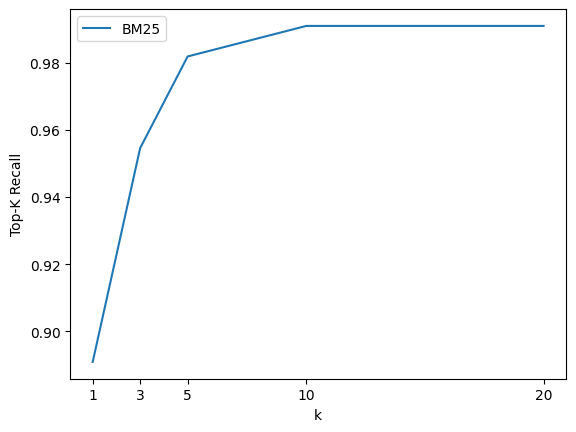

In [ ]:
plot_retriever_eval([bm25_topk_df], ["BM25"])

### Dense Passage Retrieval
One limitation of sparse retrievers like BM25 is that they can fail to capture the relevant documents if the user query contains terms that don't match exactly those of the review. One alternative is to use dense embeddings to represent the question and document, and the current state-of-the-art is an architecture known as Dense Passage Retrieval(DPR). The main idea behind DPR is to use 2 BERT models as encoders for the question and the passage, these encoders map the input text into a d-dimensional vector representation of the [CLS] token.

Let's use BERT encoders the question and passage. These encoders are trained by giving them questions with relevant(positive) passages and irrelevant(negative) passages, where the goal is to learn that relevant question-passage pairs have a a higher similarity. For this tutorial, encodrs that have been trained on the NQ corpus in this way is used

In [ ]:
from haystack.nodes import DensePassageRetriever

dpr_retriever = DensePassageRetriever(document_store=document_store,
                query_embedding_model="facebook/dpr-question_encoder-single-nq-base",
                passage_embedding_model="facebook/dpr-ctx_encoder-single-nq-base",
                embed_title=False
                                      )

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Once the dense retriever is initialized, the next step is to iterate over all the indexed documents in elasticsearch index and apply the encoders to update the embedding representation.

In [ ]:
document_store.update_embeddings(retriever=dpr_retriever)

Updating embeddings:   0%|          | 0/1615 [01:31<?, ? Docs/s]


KeyboardInterrupt: ignored

In [ ]:
dpr_topk_df = evaluate_retriever(dpr_retriever)
plot_retriever_eval([bm25_topk_df, dpr_topk_df], ["BM25", "DPR"])

Performing similarity search of the embeddings can be sped up by using Facebook's FAISS library as the document store. Similarly, the performance of the DPR retriever can be improved by fine-tuning on the target domain. checkout https://oreil.ly/eXyro

### Evaluating the Reader

Metrics for evaluating readers:
- Exact match(EM): A binary metric that gives EM=1 if the characters in the predicted and ground truth answers match exactly, and EM=0 otherwise. If no answer is expected, the model gets EM=0 if it predicts any text at all.

- $F_1$-score: Measures the harmonic mean of the precision and recall.

In [ ]:
from haystack.modeling.evaluation.squad import compute_f1, compute_exact


In [ ]:
pred = "about 6000 hours"
label = "6000 hours"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

EM: 0
F1: 0.8


Under the hood, these functions first normalize the prediction and label by removing punctuation, fixing whitespace, and converting to lowercase. The normalized strings are then tokenized as a bag-of-words, before finally computing the metric at the token level. The EM is a much stricter metric than the $F_1$-score: adding a single token to the prediction gives an EM of zero. On the other hand, the $F_1$-score can fail to catch truly incorrect answers.

In [ ]:
pred = "about 6000 dollars"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

EM: 0
F1: 0.4


Relying on just the $F_1$-score is thus misleading, and tracking both metrics is a good strategy to balance the trade-off between underestimating (EM) and overestimating ($F_1$-score) model performance.

In general, there are multiple valid answers per question, so these metrics are calculated for each question-answer pair in the evaluation set, and the best score is selected over all possible answers. The overall EM and $F_1$ scores for the model are then obtained by averaging over the individual scores of each question-answer pair.



In [ ]:
# Evaluate a reader
from haystack.pipelines import Pipeline

In [ ]:
def evaluate_reader(reader):
    score_keys = ['exact_match', 'f1']
    p = Pipeline()
    p.add_node(component=reader, name="Reader",
               inputs=["Query"])
    eval_result = p.eval(
        labels=labels_agg,
        documents=[
            [label.document for label in multilabel.labels]
            for multilabel in labels_agg
        ],
        params={}
    )
    metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
    return {
        k:v for k, v in metrics["Reader"].items()
        if k in score_keys
    }

reader_eval = {}
reader_eval["Fine-tune on SQuAD"] = evaluate_reader(reader)

KeyboardInterrupt: ignored

In [ ]:
def plot_reader_eval(reader_eval):
    fig, ax = plt.subplots()
    df = pd.DataFrame.from_dict(
        reader_eval
    ).reindex(["exact_match", "f1"])
    df.plot(kind="bar", ylabel="Score", rot=0, ax=ax)
    ax.set_xticklabels(["EM", "F1"])
    plt.legend(loc="upper left")
    plt.show()

In [ ]:
plot_reader_eval(reader_eval)

A fine-tuned model can perform significantly worse on a dataset it wasn't trained on than on one it was trained on. One reason for this possible performance drop is difference in the language, one could be formal and the other dataset informal. Another factor is likely the inherent subjectivity of the dataset, where both questions and answers differ from the factual information that may be contained in the train dataset.

Let's fine tune a model on a dataset to get better results with domain adaptation.

The FARMReader has a train() method for fine tuning reader models.

In [ ]:
# function to convert data to SubjaQA format
def create_paragraphs(df):
    paragraphs = []
    id2context = dict(zip(df["review_id"], df["context"]))
    for review_id, review in id2context.items():
        qas = []
        # Filter for all question-answer pairs about a specific context
        review_df = df.query(f"review_id == '{review_id}'")
        id2question = dict(zip(review_df["id"], review_df["question"]))
        # Build up the qas array
        for qid, question in id2question.items():
            # Filter for a single Question ID
            question_df = df.query(f"id == '{qid}'"
            ).to_dict(orient="list")
            ans_start_idxs = question_df["answers.answer_start"][0].tolist()
            ans_text = question_df["answers.text"][0].tolist()
            # Fill answerable questions
            if len(ans_start_idxs):
                answers = [
                    {"text": text, "answer_start": answer_start}
                    for text, answer_start in zip(ans_text, ans_start_idxs)
                ]
                is_impossible = False
            else:
                answers = []
                is_impossible = True
            # Add question-answer pairs to qas
            qas.append({
                "question": question,
                "id": qid,
                "is_impossible": is_impossible,
                "answers": answers
            })
        # Add context and question-answer pairs to paragraphs
        paragraphs.append({
            "qas": qas,
            "context": review
        })
    return paragraphs


In [ ]:
product = dfs["train"].query("title == 'B00001P4ZH'")

In [ ]:
product

,domain,nn_mod,nn_asp,query_mod,query_asp,q_reviews_id,question_subj_level,ques_subj_score,is_ques_subjective,review_id,id,title,context,question,answers.text,answers.answer_start,answers.answer_subj_level,answers.ans_subj_score,answers.is_ans_subjective
0,electronics,great,bass response,excellent,bass,0514ee34b672623dff659334a25b599b,5,0.5,False,882b1e2745a4779c8f17b3d4406b91c7,2543d296da9766d8d17d040ecc781699,B00001P4ZH,"I have had Koss headphones in the past, Pro 4A...",How is the bass?,[],[],[],[],[]
1,electronics,harsh,high,not strong,bass,7c46670208f7bf5497480fbdbb44561a,1,0.5,False,ce76793f036494eabe07b33a9a67288a,d476830bf9282e2b9033e2bb44bbb995,B00001P4ZH,To anyone who hasn't tried all the various typ...,Is this music song have a goo bass?,"[Bass is weak as expected, Bass is weak as exp...","[1302, 1302]","[1, 1]","[0.5083333, 0.5083333]","[True, True]"
2,electronics,neutral,sound,present,bass,8fbf26792c438aa83178c2d507af5d77,1,0.5,False,d040f2713caa2aff0ce95affb40e12c2,455575557886d6dfeea5aa19577e5de4,B00001P4ZH,I have had many sub-$100 headphones from $5 Pa...,How is the bass?,[The only fault in the sound is the bass],[650],[2],[0.6333333],[True]


In [ ]:
create_paragraphs(product)

[{'qas': [{'question': 'How is the bass?',
    'id': '2543d296da9766d8d17d040ecc781699',
    'is_impossible': True,
    'answers': []}],
  'context': 'I have had Koss headphones in the past, Pro 4AA and QZ-99.  The Koss Portapro is portable AND has great bass response.  The work great with my Android phone and can be "rolled up" to be carried in my motorcycle jacket or computer bag without getting crunched.  They are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day.  The sound is night and day better than any ear-bud could be and are almost as good as the Pro 4AA.  They are "open air" headphones so you cannot match the bass to the sealed types, but it comes close. For $32, you cannot go wrong.'},
 {'qas': [{'question': 'Is this music song have a goo bass?',
    'id': 'd476830bf9282e2b9033e2bb44bbb995',
    'is_impossible': False,
    'answers': [{'text': 'Bass is weak as expected', 'answer_start': 1302},
     {'text': 'Bass i

In [ ]:
import json
def convert_to_squad(dfs):
    for split, df in dfs.items():
        subjqa_data = {}
        # Create `paragraphs` for each product ID
        groups = (df.groupby("title").apply(
            create_paragraphs
        ).to_frame(
            name="paragraphs"
        ).reset_index())
        subjqa_data["data"] = groups.to_dict(orient="records")
        # Save the result to disk
        with open(f"electronics-{split}.json", "w+", encoding="utf-8") as f:
            json.dump(subjqa_data, f)

In [ ]:
convert_to_squad(dfs)

In [ ]:
train_filename = "electronics-train.json"
dev_filename = "electronics-validation.json"

reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename)

Preprocessing dataset:   0%|          | 0/3 [00:00<?, ? Dicts/s]WARNING:haystack.modeling.data_handler.processor:Answer 'These earbuds are nothing special. Their best attribute is that they are cheap. The sound from them is nothing special. In comparison to my standard white IPod buds these seem to emphasize the higher frequencies. There seems to be nothing happening in the bass range with these. I don't think they are efficient enough to have much bass at all. To be fair, my IPod buds overly emphasize bass so they are not that accurate either. I also compared these to a pricy Sennheiser set that I've owned for a couple of years and let's just say there is a reason why the Sennheisers cost more.Surely these Panasonic buds are very nice to use if you think they might get damaged somehow in use as it will not break your heart to have to replace them. These might be especially useful if you only listen to talk radio or have high frequency hearing loss. If you really like to listen to the 

KeyboardInterrupt: ignored

In [ ]:
reader_eval["Fine-tune on SQuAD + SubjQA"] = evaluate_reader(reader)
plot_reader_eval(reader_eval)

Doomain adaptation increases our scores, one reason we didn't fine tune a pretrained language model directly on the SubjQA training set is because we only have 1295 training examples in the SubjQA while SQuAD has over 100,000 so we might run into challenges with overfitting.

Let's look at what naive fine-tuning produces


In [ ]:
minilm_ckpt = "microsoft/MiniLM-L12-H384-uncased"
minilm_reader = FARMReader(
    model_name_or_path=minilm_ckpt,
    progress_bar=False,
    max_seq_len=max_seq_length,
    doc_stride=doc_stride,
    return_no_answer=True
)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/133M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at microsoft/MiniLM-L12-H384-uncased and are newly initialized: ['qa_outputs.weight', 'qa_outputs.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
minilm_reader.train(data_dir=".",
                    use_gpu=True,
                    n_epochs=1,
                    batch_size=16,
                    train_filename=train_filename,
                    dev_filename=dev_filename)

Preprocessing dataset:   0%|          | 0/3 [00:00<?, ? Dicts/s]WARNING:haystack.modeling.data_handler.processor:Answer 'These earbuds are nothing special. Their best attribute is that they are cheap. The sound from them is nothing special. In comparison to my standard white IPod buds these seem to emphasize the higher frequencies. There seems to be nothing happening in the bass range with these. I don't think they are efficient enough to have much bass at all. To be fair, my IPod buds overly emphasize bass so they are not that accurate either. I also compared these to a pricy Sennheiser set that I've owned for a couple of years and let's just say there is a reason why the Sennheisers cost more.Surely these Panasonic buds are very nice to use if you think they might get damaged somehow in use as it will not break your heart to have to replace them. These might be especially useful if you only listen to talk radio or have high frequency hearing loss. If you really like to listen to the 

In [ ]:
reader_eval["Fine-tune on SubjQA"] = evaluate_reader(minilm_reader)
plot_reader_eval(reader_eval)

NameError: ignored

We can see from above that fine-tuning the language model directly on SubjQA results in considerably worse performance than fine-tuning on SQuAD and SubjQA. When dealing with small datasets, it is best practice to use cross-validation when evaluating transformers as they can be prone to overfitting. Check out https://oreil.ly/K3nK8

In [ ]:
# Evaluating the Whole QA Pipeline
pipe = ExtractiveQAPipeline(
            retriever=bm25_retriever,
            reader=reader)

# Evaluate !
eval_result = pipe.eval(
    labels=labels_agg,
    params={}
)

metrics = eval_result.calculate_metrics(
    simulated_top_k_reader=1
)
# Extract metrics from reader
reader_eval["QA Pipeline (top-1)"] = {
    k:v for k, v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]
}

In [ ]:
plot_reader_eval({
    "Reader": reader_eval["Fine-tune on SQuAD + SubjQA"],
    "QA pipleine (top-1)": reader_eval["QA Pipeline (top-1)"]
})

In [ ]:
# or get QA pipeline and Reader metrics in one shot:
# Reader evaluation is run a second time using simulated perfect retriever results
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
    add_isolated_node_eval=True
)
metrics = eval_result.calculate_metrics(
    simulated_top_k_reader=1
)
# Extract metrics from reader run in isolation with simulated perfect retriever
isolated_metrics = eval_result.calculate_metrics(
    simulated_top_k_reader=1,
    eval_mode="isolated"
)

### Abstractive or Generative QA
This has the potential to produce better-phrased answers that synthesize evidence across multiple passages.
current state of the art: RAG(Retrieval Augmented Generation)

RAG extends the classic retriever-reader architecture by swapping the reader for a generator and using DPR as the retriever. The generator is a pretrained sequence to sequence transformer like T5 or BART that receives latent vectors of ducuments from DPR and then iteratively generates an answer based on the query and these documents.

RAG Models:
- RAG-Sequence: Uses the same retrieved document to generate the complete answer. In particular, the top k documents from the retriever are fed to the generator, which produces an output sequence for each document, and the result is marginalized to obtain the best answer.
- RAG-Token: Can use a different document to generate each token in the answer, this allows the generator to synthesize evidence from multiple documents.

RAG-Token models tend to perform better than RAG-Sequence ones.

### RAGenerator Deprecation
RAGenerator has been deprecated from haystack cause
- they don't perform particularly well
- they are tightly coupled with Dense Passage Retrievers (which themselves don't perform well)
- So, in real-world applications, it is more common to implement Retrieval Augmented Generation using the [PromptNode](https://haystack.deepset.ai/tutorials/22_pipeline_with_promptnode).
- The PromptNode allows the usage of several LLMs, including Hugging Face text and text2text-generation models.


In [ ]:
# from haystack.nodes import RAGenerator
from haystack.nodes import RAGenerator


generator = RAGenerator(
    model_name_or_path="facebook/rag-token-nq",
    embed_title=False, num_beams=5
)

ImportError: ignored

In [ ]:
from haystack.pipelines import GenerativeQAPipeline

pipe = GenerativeQAPipeline(generator=generator, retriever=dpr_retriever)

ModuleNotFoundError: ignored

In [ ]:
def generate_answers(query, top_k_generator=3):
    preds = pipe.run(query=query,
                     params={
                         "Retriever": {
                             "top_k": 5,
                             "filters": {
                                 "item_id": [ "B0074BW614"]
                             }
                         },
                         "Generator": {
                             "top_k": top_k_generator
                         }
                     })
    print(f"Question: {preds['query']}\n")
    for idx in range(top_k_generator):
        print(f"Answer {idx+1}: {preds['answers'][idx].answer}")

In [ ]:
generate_answers("What is the main drawback")

NameError: ignored

https://oreil.ly/Fd6lc